In [8]:
import numpy as np
import pandas as pd
from scipy import stats

import matplotlib.pyplot as plt

# __Examples: Hypothesis testing__

## __Learning objectives__

- Understand the fundamentals of hypothesis testing.
- Understand and differentiate between Type I and Type II errors.
- Know how to test the equality of means for known and unknown population variance.
- Know how to test goodness of fit and sample variances using the chi-squared distribution.

## __Introduction__

The art of data science lies in understanding the story behind data and what it is telling us.

In this notebook, we will be covering the fundamentals of **hypothesis testing**, an important component in statistical inference – a powerful tool to help us understand our data. In essence, we consider our data to be the result of an experiment which allows us to confirm or reject some initial or [*a priori*](https://en.wikipedia.org/wiki/A_priori_and_a_posteriori) hypothesis we have about a key aspect of the distribution of the underlying data.

Typically we refer to this *a priori* hypothesis as the **null hypothesis**, often denoted $H_0$. Quite often we'll see it set up as a description of what would be rather dull if it were true, and in those cases, the real excitement comes from situations where we can reject the null hypothesis. For example, we might have two versions of our website marketing the ExploreAI Academy and set up a null hypothesis that they are equally likely to result in new applicants clicking on the 'Apply Now' button. The fascinating and actionable insight would come from the data confirming that we can reject the null, based on which we would adopt the more successful version and bin the one that wasn't likely to yield results.

So how do we accept or reject a hypothesis? First of all, we need to know something about the distribution of what we're testing (in the example above, that might be the difference between the mean click-through rate under 'Web Design A' and that under 'Web Design B', which under our null hypothesis would be zero). Then we use what we know about that distribution to determine how likely it is that our sample data would have been observed if the null hypothesis is true. If that likelihood is sufficiently low, then we conclude that we can reject the null hypothesis.

### __Hypothesis testing__

Let's start the illustration of this with an example concerning one observation of a random variable with a known distribution. Suppose we know that the height of data scientists around the globe is normally distributed with a mean of 1.7 metres and a standard deviation of 10 cm. If this is the true distribution, then we can easily answer questions such as: "How likely is it that a random person drawn from the population of data scientists would be 1.5 m tall, or shorter?" Let's compute this and plot where on the distribution this point lies.

In [9]:
# Parameters
mu = 1.7          # Mean height (m)
sigma = 0.1       # Standard deviation (m)

# Generate x values
x = np.linspace(1.2, 2.2, 500)

# Normal PDF
pdf = stats.norm.pdf(x, loc=mu, scale=sigma)

# Probability of height <= 1.5 m
prob = stats.norm.cdf(1.5, loc=mu, scale=sigma)

print(f"Probability that height ≤ 1.5 m: {prob:.2%}")

Probability that height ≤ 1.5 m: 2.28%


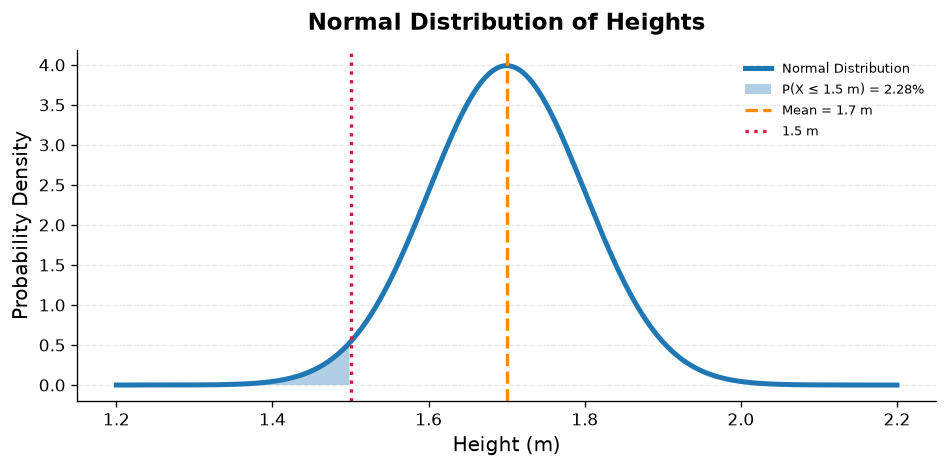

In [11]:
# Figure
fig, ax = plt.subplots(figsize=(8, 4), dpi=120)

# Density curve
ax.plot(
    x,
    pdf,
    linewidth=3,
    label="Normal Distribution"
)

# Shade probability region
mask = x <= 1.5
ax.fill_between(
    x[mask],
    pdf[mask],
    alpha=0.35,
    label=f"P(X ≤ 1.5 m) = {prob:.2%}"
)

# Mean line
ax.axvline(
    mu,
    linestyle="--",
    color='darkorange',
    linewidth=2,
    label=f"Mean = {mu:.1f} m"
)

# Reference height
ax.axvline(
    1.5,
    linestyle=":",
    linewidth=2,
    color='crimson',
    label="1.5 m"
)

# Labels
ax.set_title(
    "Normal Distribution of Heights",
    fontsize=14,
    fontweight="bold",
    pad=12
)

ax.set_xlabel("Height (m)", fontsize=12)
ax.set_ylabel("Probability Density", fontsize=12)

# Styling
ax.grid(axis="y", alpha=0.3, color = '0.75', ls="--")
ax.set_axisbelow(True)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(frameon=False, fontsize=8)

plt.tight_layout()
plt.show()

We can see that only a relatively small proportion of the probability weight lies below the 1.5 m mark, and our computation tells us that the probability of a random individual from this population being 1.5 m tall or less is about 2.3%. So we would only expect to observe a height as low as this about once in every 44 random draws.

With hypothesis testing, we are following a very similar idea, but turning things on their head a little. Here we don't know the population parameters for sure, but are [*hypothesising*](https://en.wikipedia.org/wiki/Hypothesis) what they are. The question we're asking is effectively the reverse of what we did above: Given an observed sample mean, how likely is it that the hypothesised population mean is the true population mean? To answer this question using the normal distribution, we must know what the distribution of the sample mean is, given the null hypothesis. Fortunately, we can calculate the sample mean: $\bar{X} \sim N \left( \mu, \frac{\sigma^2}{n} \right)$. Here $\mu$ (mean) and $\sigma^2$ (variance) are the parameters under the null hypothesis, and $n$ is the size of the sample.

To test our null hypothesis, we calculate a **test statistic**: the size of which tells us whether we can accept or reject the null hypothesis. It should be clear that the data can never tell us completely whether or not the hypothesis is true; this is ultimately a probabilistic judgement. Maybe "Web Design A" is just as good as "Web Design B", but it just so happened that all the people who were going to apply to the ExploreAI Academy ended up seeing the latter rather than the former... but this is unlikely, and that is the point.

Statistical inference involves deciding how unlikely we want our data to be before we can reject the null hypothesis. This level of likelihood is known as the **significance level**: if there is less than a 5% chance of having observed our data by chance if the null hypothesis is true, then we say that our outcome is significant at the 5% level (which is a common choice of cut-off in practice, though one should be wary of applying this mindlessly).

## __Exercises__

Given a population where the average weight of a species of butterfly is believed to be 150 mg with a standard deviation of 20 mg, you collect a sample of 30 butterflies and find their average weight to be 145 mg. Use a 5% significance level to test the hypothesis that the population mean weight is 150 mg against the alternative hypothesis that it is not 150 mg (determining whether the observed average weight of the sample of butterflies significantly deviates from the presumed population average weight).

In the exercises below, we will develop different functions, each responsible for a specific part of the hypothesis-testing process.

__This is a classic one-sample Z-test because:__

- Population standard deviation (σ = 20 mg) is known.
- Sample size (n = 30) is reasonably large.
- We are testing whether the population mean differs from 150 mg.

__Task 1:__

__State the null and alternative hypotheses.__

__Answer__
- __Null hypothesis ($H_0$):__ The population mean weight of the species of butterfly is 150 mg, i.e. μ = 150 mg.
- __Alternative hypothesis ($H_\alpha$):__ The population mean weight of the species of butterfly is not 150 mg, i.e. μ ≠ 150 mg.
This is a two-tailed test.

__Task 2:__

__Write a function that calculates the test statistic (z-value) based on the sample mean, population mean, population standard deviation, and sample size.__

The test statistic can be calculated using the formula for a one-sample z-test:

$$ z = \frac{\bar{x} - \mu}{\sigma / \sqrt{n}} $$

where:

- `x̄` is the sample mean.
- `μ` is the population mean under the null hypothesis.
- `σ` is the population standard deviation.
- `n` is the sample size.

In [56]:
def calculate_z_statistic(sample_mean, population_mean, population_std, sample_size):
    z = (sample_mean - population_mean) / (
        population_std / np.sqrt(sample_size)
    )
    return float(z)

In [60]:
sample_mean = 145
population_mean = 150
population_std = 20
sample_size = 30

z_value = calculate_z_statistic(
    sample_mean,
    population_mean,
    population_std,
    sample_size
)

print(f"Z-statistic : {z:.3f}")

Z-statistic : -1.369


__Task 3:__

__Write a function that returns the lower and upper critical z-values for a two-sided test at a specific significance level.__

For a two-sided z-test, the critical values are:

$ \pm z_{\alpha/2} $


where:

- α is the significance level (e.g., 0.05).
- The lower critical value is the α/2 quantile.
- The upper critical value is the 1−α/2 quantile.

Here's a clean implementation:

In [61]:
def get_critical_values(alpha):
    lower = stats.norm.ppf(alpha / 2)
    upper = stats.norm.ppf(1 - alpha / 2)

    return lower, upper  

In [62]:
lower, upper = get_critical_values(0.05)

print(f"The lower critical value is {lower:.3f}")
print(f"The upper critical value is {upper:.3f}")

The lower critical value is -1.960
The upper critical value is 1.960


__Task 4:__

__Write a function which makes a decision on whether to reject or not reject the null hypothesis based on the test statistic and critical values.__

In [45]:
def make_decision(test_statistic, lower_critical, upper_critical):

    if (test_statistic < lower_critical) or (test_statistic > upper_critical):
        return "Reject the null hypothesis"
    else:
        return "Fail to reject the null hypothesis"

In [63]:
z_value = z_value
lower, upper = get_critical_values(0.05)
decision = make_decision(z_value, lower, upper)

print(decision)

Fail to reject the null hypothesis


Since the **z-value** of `-1.37` is within the **critical values** of `-1.96` and `+1.96`, we **do not reject the null hypothesis**.

The decision to not reject the null hypothesis indicates that there isn't sufficient evidence at the 5% significance level to conclude that the population mean weight of the species of butterfly is different from 150 mg. This suggests that the observed sample mean weight of 145 mg can be attributed to sampling variability and does not provide strong evidence against the population mean being 150 mg, given the sample size and standard deviation specified.

### __Type 1 Error & Type 11 Error__

In hypothesis testing, **Type I and Type II errors** describe the two possible mistakes we can make when making a decision about the null hypothesis ($H_0$).

### __Type I Error (False Positive)__

A **Type I error** happens when we **reject the null hypothesis even though it is actually true**.

In simple terms:

> We conclude that something is happening when it actually is not.

### __Example (Butterfly weight study)__

* ($H_0$): The average butterfly weight is **150 mg**
* Reality: The true average weight is **150 mg**
* Test result: We reject ($H_0$) and say the average weight is different.

This is a **Type I error**.

### __Probability of Type I error__

The probability of making a Type I error is controlled by the **significance level ($\alpha$)**.

For example: $\alpha = 0.05$

means:

> There is a 5% chance of rejecting a true null hypothesis.

---

### __Type II Error (False Negative)__

A **Type II error** happens when we **fail to reject the null hypothesis even though it is false**.

In simple terms:

> We miss a real effect or difference that actually exists.

### __Example (Butterfly weight study)__

* ($H_0$): The average butterfly weight is **150 mg**
* Reality: The true average weight is actually **140 mg**
* Test result: We fail to reject ($H_0$) and conclude there is not enough evidence of a difference.

This is a **Type II error**.

### __Probability of Type II error__

The probability of making a Type II error is represented by: $\beta$

## Summary Table

| Reality        | Decision             | Result             |
| -------------- | -------------------- | ------------------ |
| ($H_0$) is true  | Reject ($H_0$)         | ❌ Type I Error     |
| ($H_0$) is true  | Fail to reject ($H_0$) | ✅ Correct decision |
| ($H_0$) is false | Reject ($H_0$)         | ✅ Correct decision |
| ($H_0$) is false | Fail to reject ($H_0$) | ❌ Type II Error    |

---

### __Easy way to remember__

| Error       | Meaning          | Memory Trick                         |
| ----------- | ---------------- | ------------------------------------ |
| **Type I**  | False alarm      | "I rejected something that was true" |
| **Type II** | Missed detection | "I failed to detect something false" |

### __Real-world analogy: Smoke alarm__

* **Type I error:** Smoke alarm rings, but there is no fire → false alarm.
* **Type II error:** There is a fire, but the alarm does not ring → missed danger.

In hypothesis testing:

* Lowering **$\alpha$** reduces Type I errors but may increase Type II errors.
* Increasing sample size generally reduces Type II errors and improves the test's power.


#### __Example:__

An e-commerce company wants to test whether a new website design increases the average time users spend on their platform. The historical average time spent is 4.5 minutes. The team sets up an alternative hypothesis (Ha) predicting that the new layout increases user time. Which test setup and type of error match this scenario?

__Answer:__

A one-tailed test; a Type I error occurs if they reject the null hypothesis and conclude the new design increases time, when in reality the true population mean remains unchanged.